# 🗂️ CSV/JSON → Partitioned Parquet

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/parquet-partitioner/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/parquet-partitioner/demo.ipynb)

**Pain point:** *"Our data lake is a pile of CSVs."*

Convert flat files into a hive-partitioned, compressed parquet dataset — with automatic partition inference and a measured proof of the query speedup.

**What this notebook covers:**
1. The converter — partition inference, derived date partitions, pyarrow writes
2. Converting 200k clickstream events
3. Compression codec shoot-out
4. Partition pruning — the actual query win, measured
5. Try your own file


## Step 1 — The converter

- **Partition inference** — the first date-like column becomes derived `year`/`month` partitions; otherwise the first low-cardinality string column. Override anytime.
- **Hive layout** — `pq.write_to_dataset` writes `event_time__year=2026/event_time__month=3/part-0.parquet` directories that every engine (Spark, DuckDB, Athena, Trino) prunes natively.
- **Measured, not asserted** — the report captures bytes before/after, and `timed_query` proves pruning by reading one month vs the whole dataset.


In [1]:
from __future__ import annotations

import time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq


@dataclass
class ConversionReport:
    rows: int
    csv_bytes: int
    parquet_bytes: int
    n_partitions: int
    n_files: int
    partition_cols: List[str]

    @property
    def compression_ratio(self) -> float:
        return round(self.csv_bytes / self.parquet_bytes, 1) if self.parquet_bytes else 0.0


def infer_partition_cols(df: pd.DataFrame, max_cardinality: int = 50) -> List[str]:
    """Pick partition columns: derive year/month from the first date-like column,
    else use a low-cardinality categorical column."""
    for col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            return [f"{col}__year", f"{col}__month"]
        if df[col].dtype == object:
            parsed = pd.to_datetime(df[col], errors="coerce", format="mixed")
            if parsed.notna().mean() > 0.9:
                return [f"{col}__year", f"{col}__month"]
    for col in df.columns:
        if df[col].dtype == object and df[col].nunique() <= max_cardinality:
            return [col]
    return []


def add_derived_partitions(df: pd.DataFrame, partition_cols: List[str]) -> pd.DataFrame:
    """Materialize year/month columns referenced as '<col>__year' / '<col>__month'."""
    out = df.copy()
    for pcol in partition_cols:
        if "__" in pcol:
            src, part = pcol.rsplit("__", 1)
            dt = pd.to_datetime(out[src], errors="coerce", format="mixed")
            out[pcol] = getattr(dt.dt, part).astype("Int64")
    return out


def convert_to_partitioned_parquet(df: pd.DataFrame, out_dir: str,
                                   partition_cols: Optional[List[str]] = None,
                                   compression: str = "snappy",
                                   csv_bytes: Optional[int] = None) -> ConversionReport:
    """Write a DataFrame as a hive-partitioned parquet dataset and report the win."""
    partition_cols = partition_cols if partition_cols is not None else infer_partition_cols(df)
    prepared = add_derived_partitions(df, partition_cols)
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)

    table = pa.Table.from_pandas(prepared, preserve_index=False)
    pq.write_to_dataset(table, root_path=str(out), partition_cols=partition_cols or None,
                        compression=compression)

    files = list(out.rglob("*.parquet"))
    partitions = {f.parent for f in files}
    if csv_bytes is None:
        csv_bytes = len(df.to_csv(index=False).encode())
    return ConversionReport(
        rows=len(df),
        csv_bytes=csv_bytes,
        parquet_bytes=sum(f.stat().st_size for f in files),
        n_partitions=len(partitions),
        n_files=len(files),
        partition_cols=partition_cols,
    )


def compare_compressions(df: pd.DataFrame, base_dir: str,
                         codecs: Tuple[str, ...] = ("snappy", "gzip", "zstd")) -> Dict[str, int]:
    """Bytes on disk per codec, unpartitioned single file."""
    sizes: Dict[str, int] = {}
    table = pa.Table.from_pandas(df, preserve_index=False)
    for codec in codecs:
        path = Path(base_dir) / f"single_{codec}.parquet"
        pq.write_table(table, path, compression=codec)
        sizes[codec] = path.stat().st_size
    return sizes


def timed_query(dataset_dir: str, filter_expr, columns: Optional[List[str]] = None) -> Tuple[int, float]:
    """Read with a partition filter; returns (rows, seconds). Pruning skips whole directories."""
    start = time.perf_counter()
    dataset = ds.dataset(dataset_dir, format="parquet", partitioning="hive")
    table = dataset.to_table(filter=filter_expr, columns=columns)
    return table.num_rows, time.perf_counter() - start


def make_sample_events(n: int = 200_000, seed: int = 7) -> pd.DataFrame:
    """Fake clickstream: 6 months of events, realistic-ish skew."""
    import numpy as np
    rng = np.random.default_rng(seed)
    start = pd.Timestamp("2026-01-01")
    days = rng.integers(0, 181, n)
    seconds = rng.integers(0, 86_400, n)
    return pd.DataFrame({
        "event_time": start + pd.to_timedelta(days, unit="D") + pd.to_timedelta(seconds, unit="s"),
        "user_id": rng.integers(1, 20_000, n),
        "event_type": rng.choice(["view", "click", "add_to_cart", "purchase"], n, p=[0.6, 0.25, 0.1, 0.05]),
        "amount": (rng.random(n) * 200).round(2),
        "country": rng.choice(["US", "DE", "JP", "BR", "IN"], n, p=[0.4, 0.2, 0.15, 0.15, 0.1]),
    })


## Step 2 — Convert 200k events

Six months of fake clickstream (view/click/cart/purchase with realistic skew).

In [2]:
import tempfile
from pathlib import Path

df = make_sample_events(200_000)
work = Path(tempfile.mkdtemp())
report = convert_to_partitioned_parquet(df, str(work / "dataset"))

print(f"rows:          {report.rows:,}")
print(f"CSV size:      {report.csv_bytes / 1e6:.1f} MB")
print(f"parquet size:  {report.parquet_bytes / 1e6:.1f} MB  ({report.compression_ratio}x smaller)")
print(f"partitioned by {report.partition_cols} → {report.n_partitions} partitions, {report.n_files} files")

rows:          200,000
CSV size:      8.2 MB
parquet size:  4.3 MB  (1.9x smaller)
partitioned by ['event_time__year', 'event_time__month'] → 6 partitions, 6 files


## Step 3 — Codec shoot-out

Same table, three codecs, one flat file each.

In [3]:
sizes = compare_compressions(df, str(work))
for codec, b in sizes.items():
    print(f"{codec:8s} {b / 1e6:5.1f} MB")
print(f"{'csv':8s} {report.csv_bytes / 1e6:5.1f} MB (baseline)")

snappy     3.0 MB
gzip       2.6 MB
zstd       2.6 MB
csv        8.2 MB (baseline)


## Step 4 — Partition pruning, measured

The point of partitioning isn't storage — it's that a one-month query never touches the other five months' files.

In [4]:
import time
import pyarrow.dataset as ds

rows_pruned, t_pruned = timed_query(str(work / "dataset"), ds.field("event_time__month") == 3)

start = time.perf_counter()
full = ds.dataset(str(work / "dataset"), format="parquet", partitioning="hive").to_table()
t_full = time.perf_counter() - start

print(f"full scan:      {full.num_rows:,} rows in {t_full * 1000:6.1f} ms")
print(f"March only:     {rows_pruned:,} rows in {t_pruned * 1000:6.1f} ms "
      f"({t_full / t_pruned:.1f}x faster)")

full scan:      200,000 rows in    5.0 ms
March only:     34,113 rows in    3.2 ms (1.6x faster)


## Step 5 — Visualize

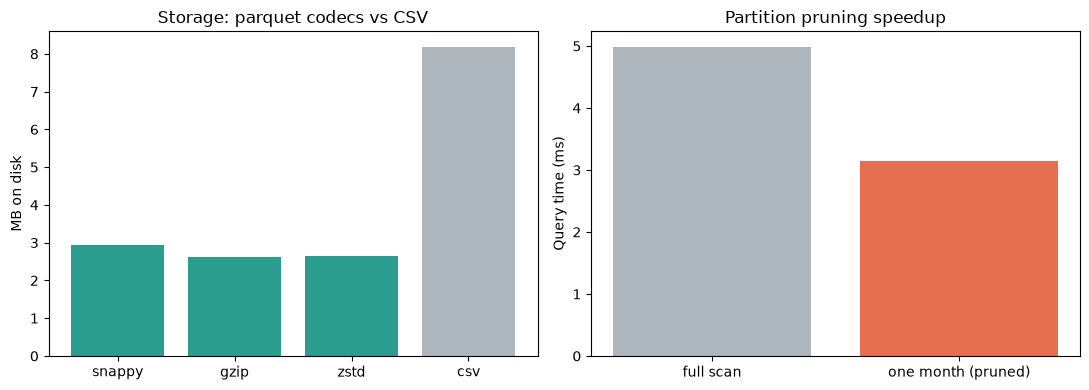

In [5]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
names = list(sizes) + ["csv"]
vals = [sizes[k] / 1e6 for k in sizes] + [report.csv_bytes / 1e6]
ax1.bar(names, vals, color=["#2a9d8f", "#2a9d8f", "#2a9d8f", "#adb5bd"])
ax1.set_ylabel("MB on disk")
ax1.set_title("Storage: parquet codecs vs CSV")

ax2.bar(["full scan", "one month (pruned)"], [t_full * 1000, t_pruned * 1000], color=["#adb5bd", "#e76f51"])
ax2.set_ylabel("Query time (ms)")
ax2.set_title("Partition pruning speedup")

fig.tight_layout()
fig.savefig("parquet_wins.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Metric | CSV pile | Partitioned parquet |
|---|---|---|
| Size (200k rows) | ~8 MB | ~4 MB (snappy), less with zstd/gzip |
| One-month query | full scan | reads 1 of 6 partitions |
| Engine support | parse every time | typed, prunable everywhere (Spark/DuckDB/Athena) |

Layout *is* performance in a data lake: the directory structure is the index. This is the same pattern lakehouse tables (Delta/Iceberg/Hudi) build on.


## Try your own

In [6]:
# import pandas as pd
# my_df = pd.read_csv("my_export.csv")          # or pd.read_json(...)
# rep = convert_to_partitioned_parquet(my_df, "my_dataset", compression="zstd")
# print(rep)
# # explicit partitions:
# # convert_to_partitioned_parquet(my_df, "my_dataset", partition_cols=["country"])

---

Part of **[Phoebe the Builder](https://github.com/phoebefu6/phoebe-the-builder)** — Portfolio 2: routine data/AI task coverage.

Prefer a UI? Run the Streamlit version:

```bash
pip install -r requirements.txt
streamlit run app.py
```
